In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
pd.set_option('display.max_columns', None)

# Seaborn theme
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load dataset
df = pd.read_csv("../data/ai_impact_students.csv")

# Display first 5 rows
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [4]:
# Check number of rows and columns
df.shape

(50000, 16)

In [5]:
# View column names
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')

In [6]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [7]:
# Statistical summary
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [8]:
# Random sample rows
df.sample(5)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
20259,120260,Business,Junior,1.936,0.93,Copywriting/Drafting,Beginner,2,False,3.45,4,Strict_Ban,5,1.930,52.58,Medium
5697,105698,Humanities,Freshman,3.099,7.24,Summarizing_Reading,Beginner,3,False,13.10,1,Allowed_With_Citation,8,3.456,76.67,Low
40407,140408,Medical,Sophomore,2.833,10.15,Summarizing_Reading,Intermediate,5,False,18.46,1,Strict_Ban,3,2.884,47.99,Medium
9469,109470,Humanities,Junior,2.849,1.86,Copywriting/Drafting,Advanced,5,False,15.81,2,Allowed_With_Citation,3,3.394,70.62,Low
35345,135346,Arts,Junior,3.822,0.11,Ideation,Advanced,4,True,7.94,1,Allowed_With_Citation,1,3.850,82.86,Medium


# AI Impact on Students — Exploratory Data Analysis

## Project Objective

This project analyzes how Generative AI usage impacts student academic performance, study behavior, dependency levels, and burnout risk.

The dataset contains 50,000 student records with information related to:
- GPA changes
- AI usage hours
- prompt engineering skills
- study habits
- burnout risk
- anxiety levels
- institutional AI policies

The objective of this analysis is to uncover meaningful patterns and insights that educational institutions, researchers, and HR teams can use to understand the academic and behavioral effects of AI adoption among students.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [9]:
# Check missing values
missing_values = df.isnull().sum()

# Display missing values
missing_values

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [10]:
# Missing values percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Student_ID,0,0.0
Major_Category,0,0.0
Year_of_Study,0,0.0
Pre_Semester_GPA,0,0.0
Weekly_GenAI_Hours,0,0.0
Primary_Use_Case,0,0.0
Prompt_Engineering_Skill,0,0.0
Tool_Diversity,0,0.0
Paid_Subscription,0,0.0
Traditional_Study_Hours,0,0.0


## Missing Value Analysis

The dataset was checked for missing values to ensure data quality before analysis.

Both the count and percentage of missing values were calculated for each column. Missing values can impact statistical analysis, visualizations, and model accuracy.

Columns with insignificant missing percentages may be handled through row removal, while larger missing percentages may require imputation or exclusion depending on business relevance.

In [11]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [12]:
# Check datatypes
df.dtypes

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object

In [13]:
# Example datatype correction

# Convert categorical columns
categorical_cols = [
    'Major_Category',
    'Primary_Use_Case',
    'Paid_Subscription',
    'Institutional_Policy',
    'Burnout_Risk_Level'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Datatype conversion completed.")

Datatype conversion completed.


## Data Type Validation

The dataset data types were reviewed to ensure each column used an appropriate format.

Categorical columns were converted into category data types to improve memory efficiency and analytical clarity.

In [14]:
# Check unique values in categorical columns

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Year_of_Study
<StringArray>
['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']
Length: 5, dtype: str

Column: Prompt_Engineering_Skill
<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str


C:\Users\piyus\AppData\Local\Temp\ipykernel_10432\927447817.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [15]:
# Remove leading/trailing spaces
for col in categorical_cols:
    df[col] = df[col].str.strip()

# Standardize capitalization
for col in categorical_cols:
    df[col] = df[col].str.title()

print("Categorical values standardized.")

Categorical values standardized.


## Categorical Data Standardization

Categorical columns were checked for inconsistencies such as:
- inconsistent capitalization
- leading/trailing spaces
- spelling variations

Standardization was applied to ensure accurate grouping and visualization during analysis.

In [16]:
# Final dataset check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Student_ID                  50000 non-null  int64   
 1   Major_Category              50000 non-null  category
 2   Year_of_Study               50000 non-null  str     
 3   Pre_Semester_GPA            50000 non-null  float64 
 4   Weekly_GenAI_Hours          50000 non-null  float64 
 5   Primary_Use_Case            50000 non-null  category
 6   Prompt_Engineering_Skill    50000 non-null  str     
 7   Tool_Diversity              50000 non-null  int64   
 8   Paid_Subscription           50000 non-null  category
 9   Traditional_Study_Hours     50000 non-null  float64 
 10  Perceived_AI_Dependency     50000 non-null  int64   
 11  Institutional_Policy        50000 non-null  category
 12  Anxiety_Level_During_Exams  50000 non-null  int64   
 13  Post_Semester_GPA          

In [17]:
# Save cleaned dataset
df.to_csv("../data/cleaned_ai_impact_students.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Business Questions

The following business questions were framed before analysis to guide the exploratory data analysis process and uncover meaningful insights from the dataset.

These questions focus on understanding how Generative AI usage affects student academic performance, dependency, study behavior, and burnout risk.

## Business Questions

### 1. Does higher Generative AI usage improve student academic performance?
This question analyzes whether students spending more hours using GenAI tools achieve higher post-semester GPAs.

---

### 2. How does AI dependency relate to burnout risk among students?
This explores whether students with higher perceived dependency on AI experience greater burnout risk.

---

### 3. Do students with paid AI subscriptions perform better academically than students using free tools?
This investigates whether access to premium AI tools is associated with improved academic outcomes.

---

### 4. Which primary use case of AI is most associated with better skill retention scores?
This identifies whether using AI for learning, coding, research, assignments, or creativity impacts long-term skill retention differently.

---

### 5. Is there a relationship between traditional study hours and anxiety levels during exams?
This examines whether students who spend more time studying traditionally experience lower or higher exam anxiety.

# Exploratory Data Analysis (EDA)

This section analyzes the dataset using statistical summaries and visualizations to answer the predefined business questions.

The analysis focuses on identifying relationships between AI usage, academic performance, burnout risk, study behavior, and skill retention among students.

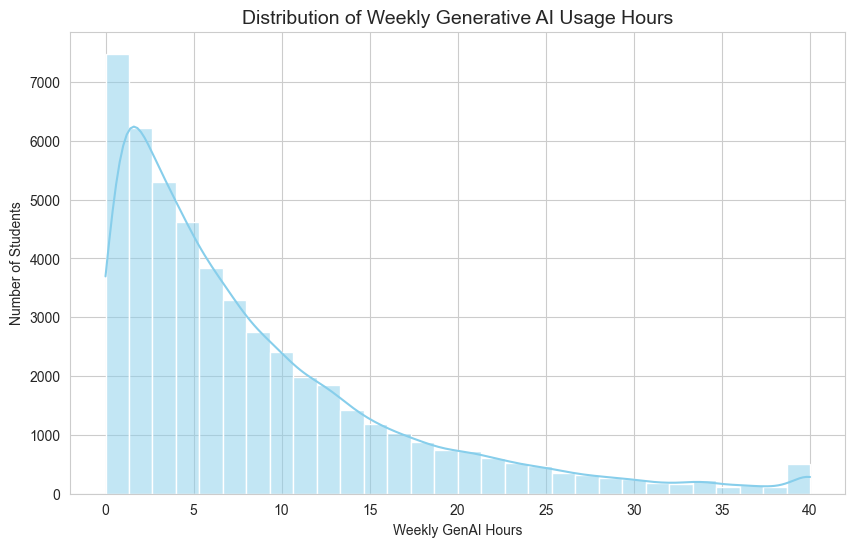

In [18]:
# Distribution of Weekly GenAI Usage

plt.figure(figsize=(10,6))

sns.histplot(
    df['Weekly_GenAI_Hours'],
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of Weekly Generative AI Usage Hours', fontsize=14)
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Number of Students')

plt.savefig("../images/distribution_genai_usage.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The distribution plot shows how frequently students use Generative AI tools weekly.

This helps identify whether most students are light, moderate, or heavy AI users and provides context for analyzing academic outcomes.


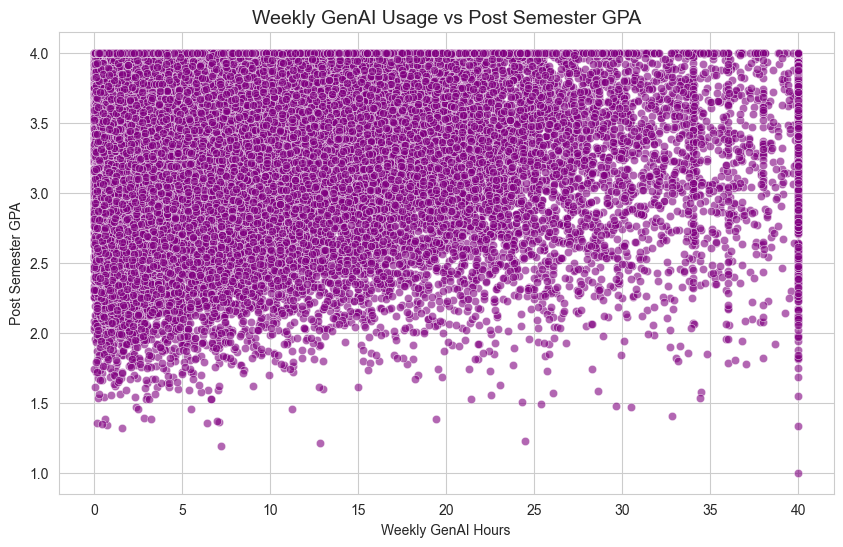

In [19]:
# Relationship between AI usage and GPA

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    data=df,
    alpha=0.6,
    color='purple'
)

plt.title('Weekly GenAI Usage vs Post Semester GPA', fontsize=14)
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Post Semester GPA')

plt.savefig("../images/ai_usage_vs_gpa.png", dpi=300, bbox_inches="tight")
plt.show()

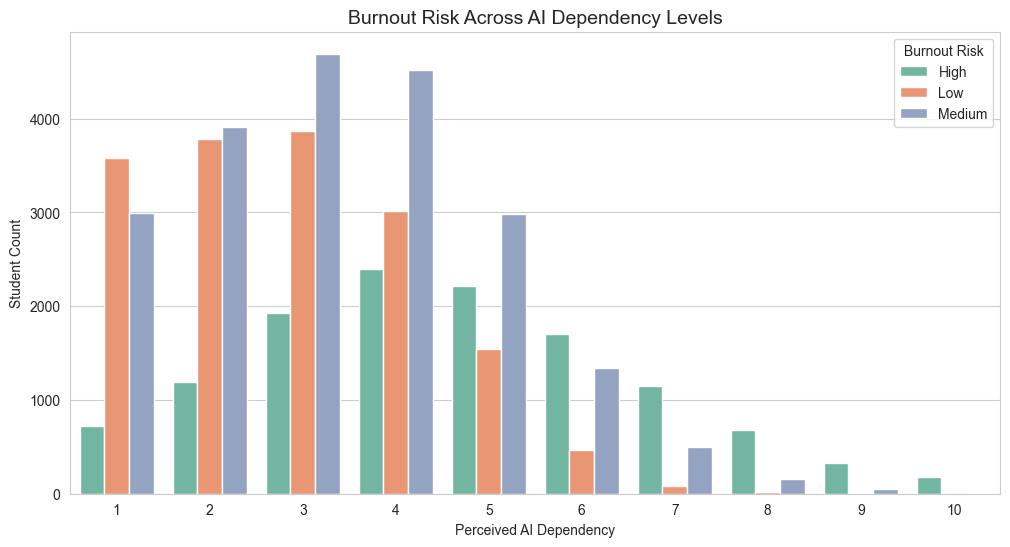

In [20]:
# Burnout risk vs AI dependency

plt.figure(figsize=(12,6))

sns.countplot(
    x='Perceived_AI_Dependency',
    hue='Burnout_Risk_Level',
    data=df,
    palette='Set2'
)

plt.title('Burnout Risk Across AI Dependency Levels', fontsize=14)
plt.xlabel('Perceived AI Dependency')
plt.ylabel('Student Count')

plt.legend(title='Burnout Risk')

plt.savefig("../images/burnout_dependency.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

The grouped bar chart compares burnout risk levels across different AI dependency categories.

This helps evaluate whether increased dependency on AI tools is associated with higher burnout risk among students.

C:\Users\piyus\AppData\Local\Temp\ipykernel_10432\2662430475.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


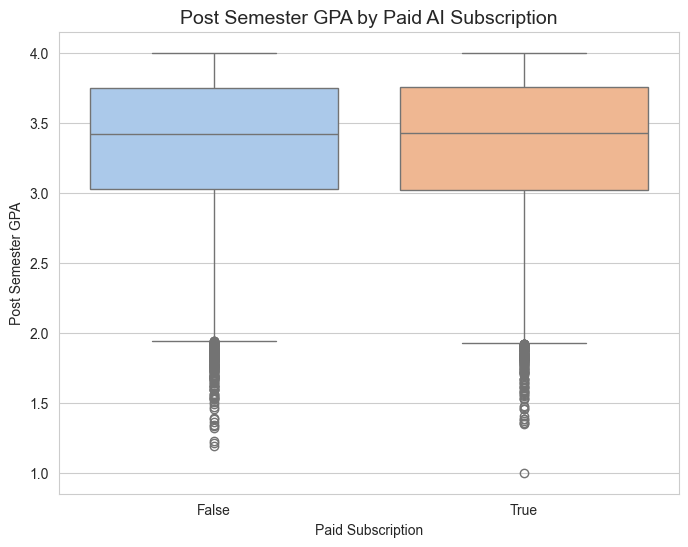

In [21]:
# Paid subscription vs GPA

plt.figure(figsize=(8,6))

sns.boxplot(
    x='Paid_Subscription',
    y='Post_Semester_GPA',
    data=df,
    palette='pastel'
)

plt.title('Post Semester GPA by Paid AI Subscription', fontsize=14)
plt.xlabel('Paid Subscription')
plt.ylabel('Post Semester GPA')

plt.savefig("../images/paid_subscription_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

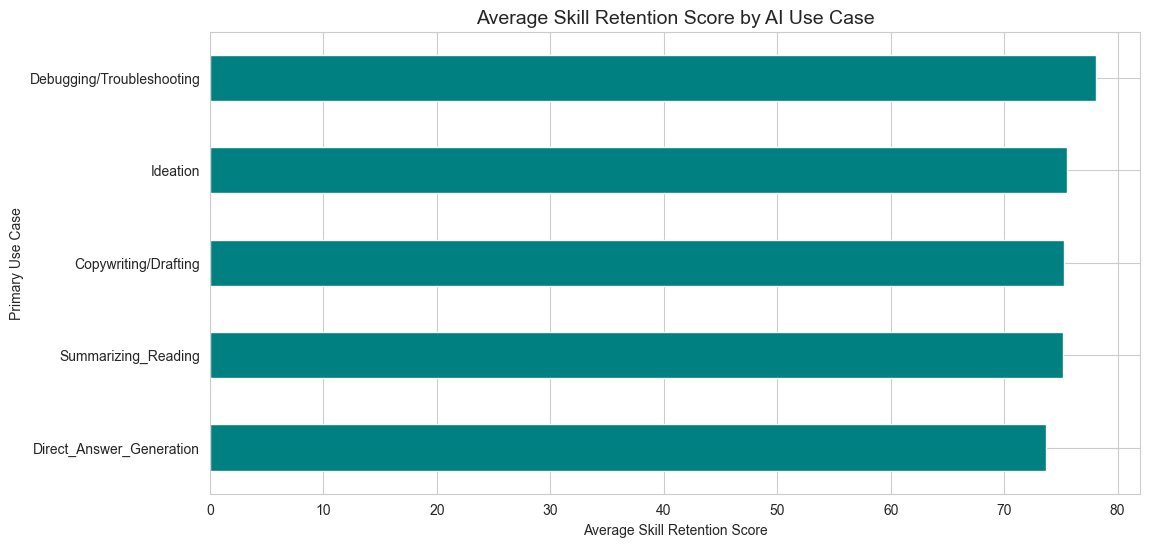

In [22]:
# Average skill retention by AI use case

avg_skill = df.groupby('Primary_Use_Case')['Skill_Retention_Score'].mean().sort_values()

plt.figure(figsize=(12,6))

avg_skill.plot(
    kind='barh',
    color='teal'
)

plt.title('Average Skill Retention Score by AI Use Case', fontsize=14)
plt.xlabel('Average Skill Retention Score')
plt.ylabel('Primary Use Case')

plt.savefig("../images/skill_retention_bar.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\piyus\AppData\Local\Temp\ipykernel_10432\1319330434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


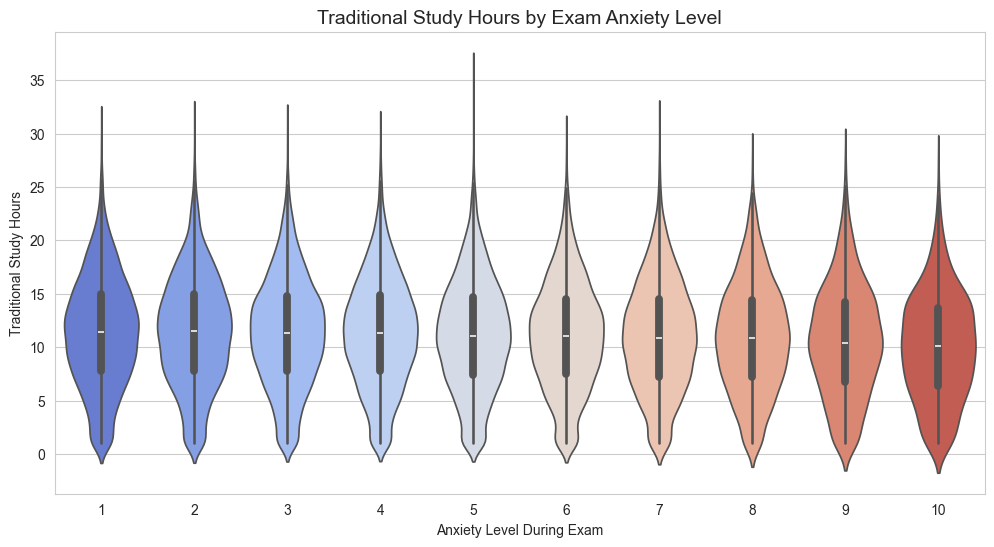

In [25]:
# Study hours vs anxiety level

plt.figure(figsize=(12,6))

sns.violinplot(
    x='Anxiety_Level_During_Exams',
    y='Traditional_Study_Hours',
    data=df,
    palette='coolwarm'
)

plt.title('Traditional Study Hours by Exam Anxiety Level', fontsize=14)
plt.xlabel('Anxiety Level During Exam')
plt.ylabel('Traditional Study Hours')

plt.savefig("../images/anxiety_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

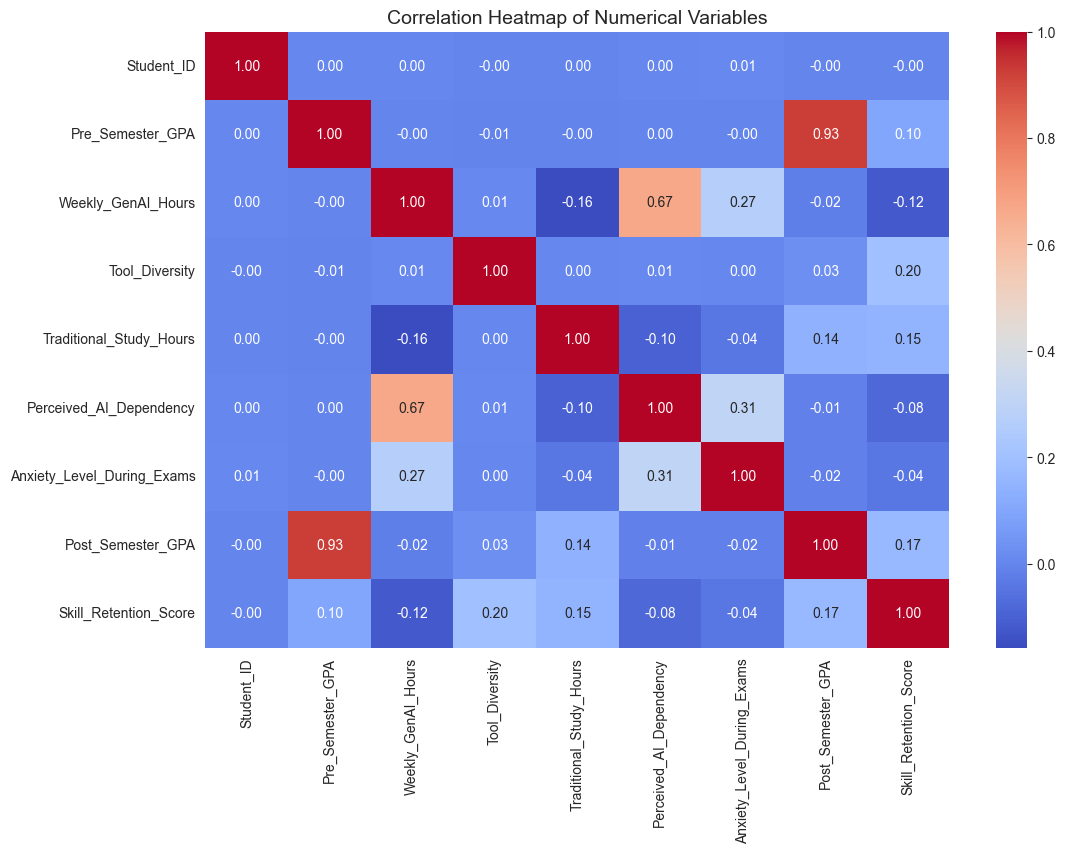

In [26]:
# Correlation heatmap

numerical_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=14)

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# Final dataset overview

print("Final Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Final Dataset Shape: (50000, 16)

Column Names:
['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']
